In [ ]:
import pandas as pd
import numpy as np

from pathlib import Path

In [ ]:
DATA_PATH="data.csv"
df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded successfully.")
print(f"Shape: {df.shape}")

Dataset loaded successfully.
Shape: (920, 16)


In [ ]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [ ]:
df.tail()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0
919,920,62,Male,VA Long Beach,atypical angina,120.0,254.0,False,lv hypertrophy,93.0,True,0.0,NaN,NaN,NaN,1


In [ ]:
print("\n--- Dataset Information ---")
df.info()


--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [ ]:
print("\n--- Column Names ---")

for i, col in enumerate(df.columns, start=1):
    print(f"{i:2}. {col}")


--- Column Names ---
 1. id
 2. age
 3. sex
 4. dataset
 5. cp
 6. trestbps
 7. chol
 8. fbs
 9. restecg
10. thalch
11. exang
12. oldpeak
13. slope
14. ca
15. thal
16. num


In [ ]:
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [ ]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": df.isnull().mean() * 100
})

missing_summary = missing_summary[
    missing_summary["missing_count"] > 0
].sort_values(
    "missing_percentage",
    ascending=False
)

print(missing_summary)

          missing_count  missing_percentage
ca                  611           66.413043
thal                486           52.826087
slope               309           33.586957
fbs                  90            9.782609
oldpeak              62            6.739130
trestbps             59            6.413043
exang                55            5.978261
thalch               55            5.978261
chol                 30            3.260870
restecg               2            0.217391


In [ ]:
categorical_cols = df.select_dtypes(
    include=["object", "category", "bool"]
).columns

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- sex ---
sex
Male      726
Female    194
Name: count, dtype: int64

--- dataset ---
dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64

--- cp ---
cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64

--- fbs ---
fbs
False    692
True     138
NaN       90
Name: count, dtype: int64

--- restecg ---
restecg
normal              551
lv hypertrophy      188
st-t abnormality    179
NaN                   2
Name: count, dtype: int64

--- exang ---
exang
False    528
True     337
NaN       55
Name: count, dtype: int64

--- slope ---
slope
flat           345
NaN            309
upsloping      203
downsloping     63
Name: count, dtype: int64

--- thal ---
thal
NaN                  486
normal               196
reversable defect    192
fixed defect          46
Name: count, dtype: int64


In [ ]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns

print("Numeric columns:")
print(list(numeric_cols))

Numeric columns:
['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num']


In [ ]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
id,920.0,460.500000,265.725422,1.0,230.75,460.5,690.25,920.0
age,920.0,53.510870,9.424685,28.0,47.00,54.0,60.00,77.0
trestbps,861.0,132.132404,19.066070,0.0,120.00,130.0,140.00,200.0
chol,890.0,199.130337,110.780810,0.0,175.00,223.0,268.00,603.0
thalch,865.0,137.545665,25.926276,60.0,120.00,140.0,157.00,202.0
oldpeak,858.0,0.878788,1.091226,-2.6,0.00,0.5,1.50,6.2
ca,309.0,0.676375,0.935653,0.0,0.00,0.0,1.00,3.0
num,920.0,0.995652,1.142693,0.0,0.00,1.0,2.00,4.0


In [ ]:
print("=== Data Validation Summary ===")

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Numeric features: {len(numeric_cols)}")
print(f"Categorical features: {len(categorical_cols)}")
print(f"Target column present: {'num' in df.columns}")

=== Data Validation Summary ===
Rows: 920
Columns: 16
Duplicate rows: 0
Missing values: 1759
Numeric features: 8
Categorical features: 8
Target column present: True


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [3]:
# Load the raw dataset.
df = pd.read_csv("data.csv")

# Keep the raw dataframe unchanged and use a separate copy for EDA.
eda_df = df.copy()

print("Dataset loaded successfully.")
print(f"Dataset shape: {eda_df.shape}")

Dataset loaded successfully.
Dataset shape: (920, 16)


In [4]:
# Separate numerical and categorical columns for EDA.
numeric_cols = eda_df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = eda_df.select_dtypes(include=["object", "category"]).columns.tolist()

# The target is excluded from feature-level analysis where appropriate.
target_col = "num"

print("Numerical columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

print(f"\nTarget column: {target_col}")

Numerical columns:
['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num']

Categorical columns:
['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

Target column: num


In [5]:
# Calculate missing-value counts and percentages.
missing_summary = pd.DataFrame({
    "Missing Count": eda_df.isnull().sum(),
    "Missing Percentage": eda_df.isnull().mean() * 100
})

missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
].sort_values("Missing Percentage", ascending=False)

print("=== Missing Value Analysis ===")
print(missing_summary)

print("\nKey findings:")

if not missing_summary.empty:
    highest_missing_col = missing_summary.index[0]
    highest_missing_pct = missing_summary.iloc[0]["Missing Percentage"]

    print(
        f"- '{highest_missing_col}' has the highest missingness "
        f"({highest_missing_pct:.2f}%)."
    )

    print(
        "- Missing values should be handled during the preprocessing stage "
        "after the train/test split to avoid data leakage."
    )
else:
    print("- No missing values were detected.")

=== Missing Value Analysis ===
          Missing Count  Missing Percentage
ca                  611           66.413043
thal                486           52.826087
slope               309           33.586957
fbs                  90            9.782609
oldpeak              62            6.739130
trestbps             59            6.413043
exang                55            5.978261
thalch               55            5.978261
chol                 30            3.260870
restecg               2            0.217391

Key findings:
- 'ca' has the highest missingness (66.41%).
- Missing values should be handled during the preprocessing stage after the train/test split to avoid data leakage.


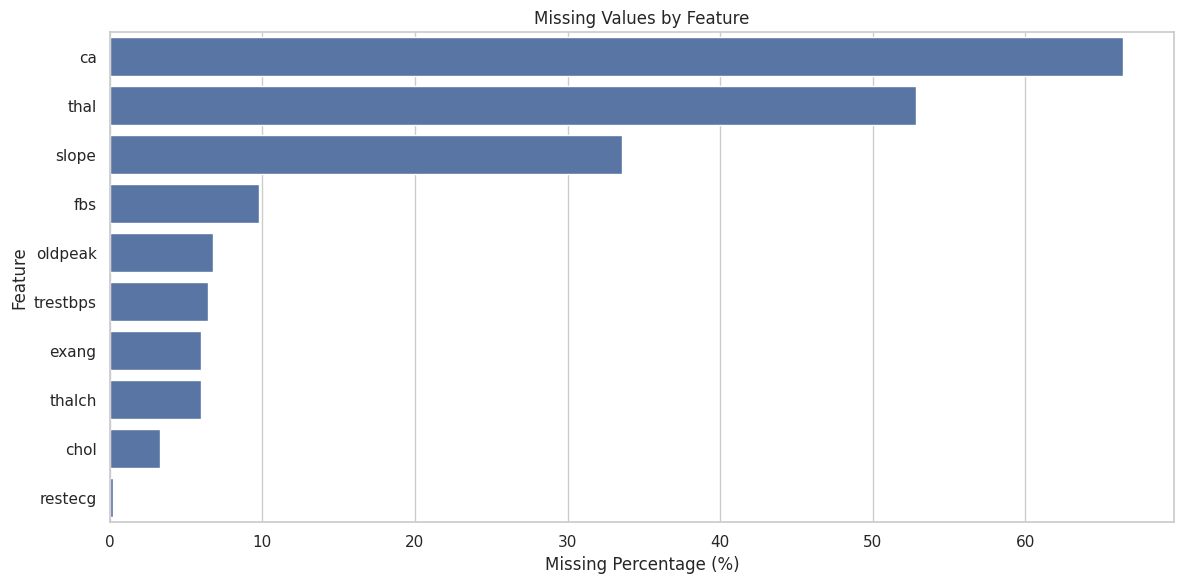


Interpretation:
- ca: 66.41% missing values.
- thal: 52.83% missing values.
- slope: 33.59% missing values.
- fbs: 9.78% missing values.
- oldpeak: 6.74% missing values.
- trestbps: 6.41% missing values.
- exang: 5.98% missing values.
- thalch: 5.98% missing values.
- chol: 3.26% missing values.
- restecg: 0.22% missing values.

The missing-value pattern indicates that some features require careful preprocessing rather than simple row deletion.


In [6]:
# Visualize the percentage of missing values in each column.
plt.figure(figsize=(12, 6))

missing_pct = eda_df.isnull().mean().sort_values(ascending=False) * 100
missing_pct = missing_pct[missing_pct > 0]

sns.barplot(
    x=missing_pct.values,
    y=missing_pct.index
)

plt.title("Missing Values by Feature")
plt.xlabel("Missing Percentage (%)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("\nInterpretation:")
for col, pct in missing_pct.items():
    print(f"- {col}: {pct:.2f}% missing values.")

print(
    "\nThe missing-value pattern indicates that some features require "
    "careful preprocessing rather than simple row deletion."
)

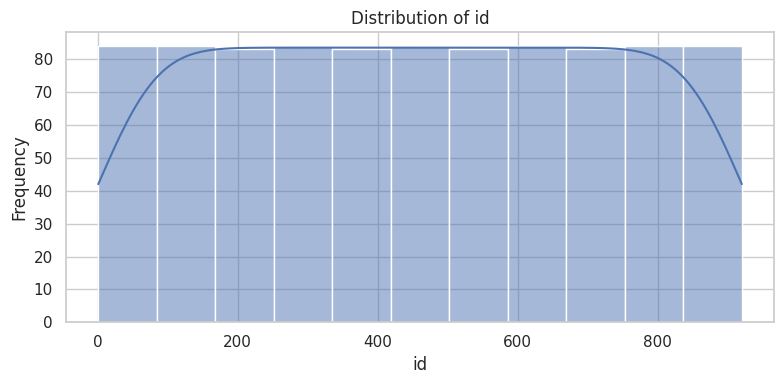


=== Distribution Analysis: id ===
Mean: 460.50
Median: 460.50
Standard deviation: 265.73
Minimum: 1.00
Maximum: 920.00
Skewness: 0.00


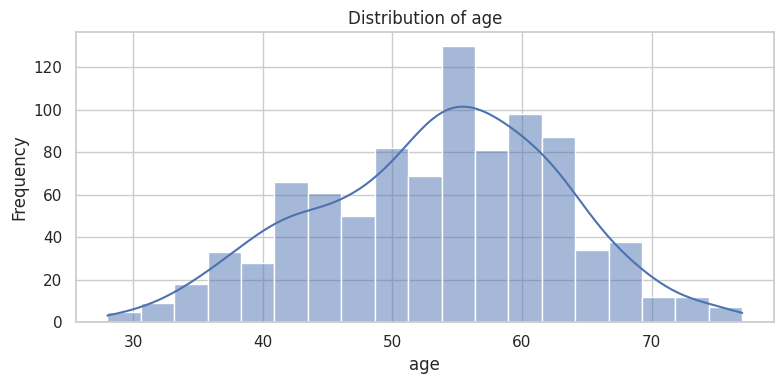


=== Distribution Analysis: age ===
Mean: 53.51
Median: 54.00
Standard deviation: 9.42
Minimum: 28.00
Maximum: 77.00
Skewness: -0.20


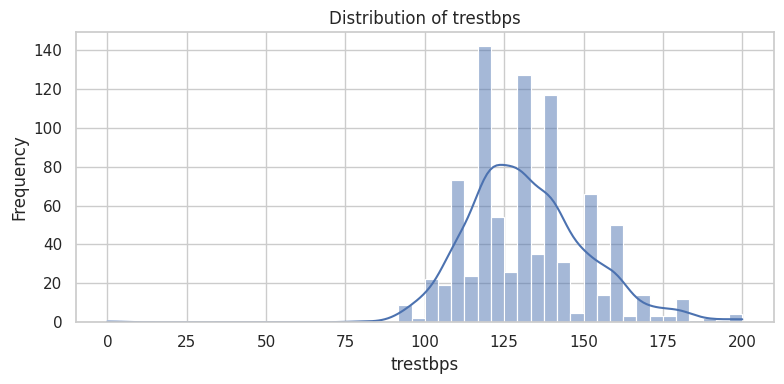


=== Distribution Analysis: trestbps ===
Mean: 132.13
Median: 130.00
Standard deviation: 19.07
Minimum: 0.00
Maximum: 200.00
Skewness: 0.21


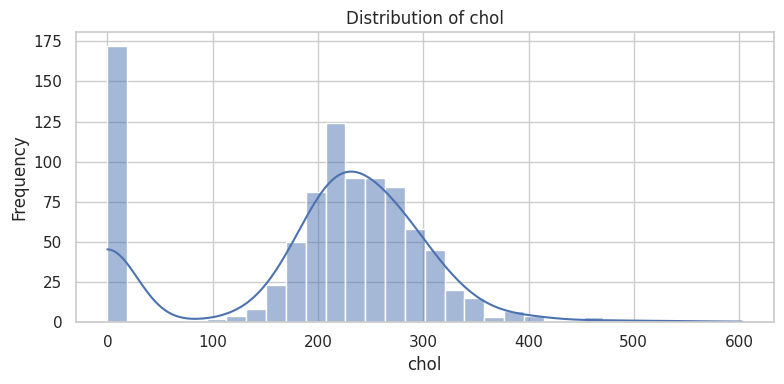


=== Distribution Analysis: chol ===
Mean: 199.13
Median: 223.00
Standard deviation: 110.78
Minimum: 0.00
Maximum: 603.00
Skewness: -0.61


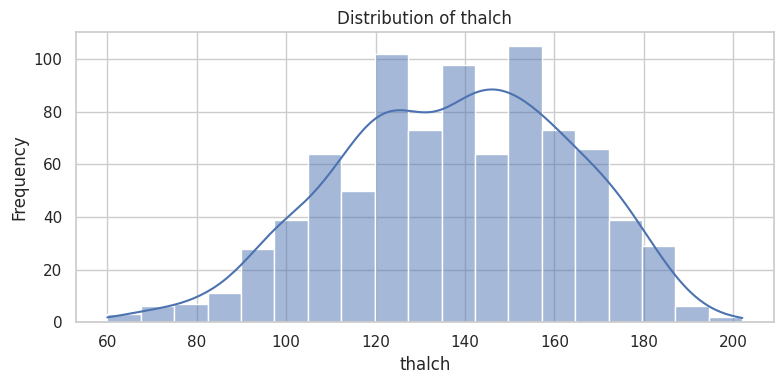


=== Distribution Analysis: thalch ===
Mean: 137.55
Median: 140.00
Standard deviation: 25.93
Minimum: 60.00
Maximum: 202.00
Skewness: -0.21


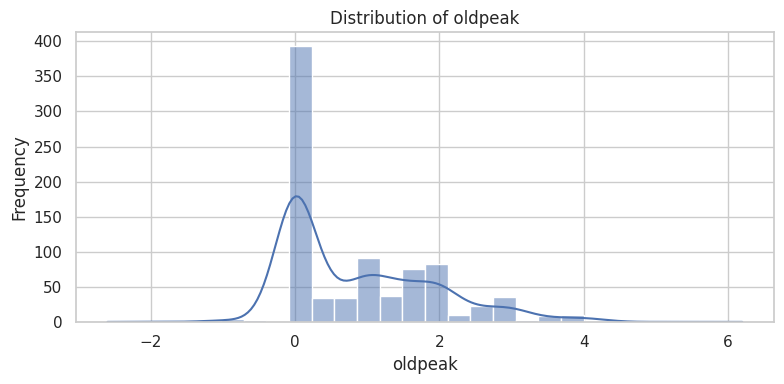


=== Distribution Analysis: oldpeak ===
Mean: 0.88
Median: 0.50
Standard deviation: 1.09
Minimum: -2.60
Maximum: 6.20
Skewness: 1.04


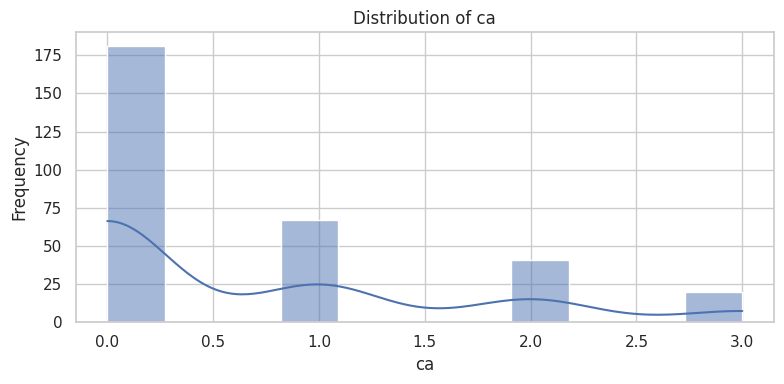


=== Distribution Analysis: ca ===
Mean: 0.68
Median: 0.00
Standard deviation: 0.94
Minimum: 0.00
Maximum: 3.00
Skewness: 1.17


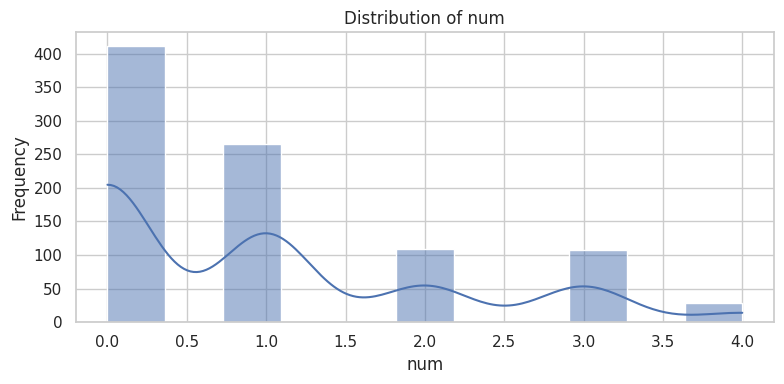


=== Distribution Analysis: num ===
Mean: 1.00
Median: 1.00
Standard deviation: 1.14
Minimum: 0.00
Maximum: 4.00
Skewness: 0.97


In [7]:
# Plot the distribution of each numerical feature.
for col in numeric_cols:

    plt.figure(figsize=(8, 4))

    sns.histplot(
        data=eda_df,
        x=col,
        kde=True
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    series = eda_df[col].dropna()

    print(f"\n=== Distribution Analysis: {col} ===")
    print(f"Mean: {series.mean():.2f}")
    print(f"Median: {series.median():.2f}")
    print(f"Standard deviation: {series.std():.2f}")
    print(f"Minimum: {series.min():.2f}")
    print(f"Maximum: {series.max():.2f}")
    print(f"Skewness: {series.skew():.2f}")

In [8]:
# Calculate skewness and kurtosis for numerical features.
distribution_analysis = []

for col in numeric_cols:

    series = eda_df[col].dropna()

    skew_value = series.skew()
    kurt_value = series.kurt()

    if skew_value > 1:
        skew_description = "Highly right-skewed"
    elif skew_value > 0.5:
        skew_description = "Moderately right-skewed"
    elif skew_value < -1:
        skew_description = "Highly left-skewed"
    elif skew_value < -0.5:
        skew_description = "Moderately left-skewed"
    else:
        skew_description = "Approximately symmetric"

    if kurt_value > 1:
        kurt_description = "Heavy-tailed"
    elif kurt_value < -1:
        kurt_description = "Light-tailed"
    else:
        kurt_description = "Relatively close to normal"

    distribution_analysis.append({
        "Feature": col,
        "Skewness": skew_value,
        "Skewness Interpretation": skew_description,
        "Kurtosis": kurt_value,
        "Kurtosis Interpretation": kurt_description
    })

distribution_analysis = pd.DataFrame(distribution_analysis)

print("=== Distribution Shape Analysis ===")
display(distribution_analysis)

=== Distribution Shape Analysis ===


,Feature,Skewness,Skewness Interpretation,Kurtosis,Kurtosis Interpretation
0,id,0.000000,Approximately symmetric,-1.200000,Light-tailed
1,age,-0.195994,Approximately symmetric,-0.382930,Relatively close to normal
2,trestbps,0.213334,Approximately symmetric,2.958664,Heavy-tailed
3,chol,-0.613836,Moderately left-skewed,0.062273,Relatively close to normal
4,thalch,-0.211119,Approximately symmetric,-0.479725,Relatively close to normal
5,oldpeak,1.041427,Highly right-skewed,1.127069,Heavy-tailed
6,ca,1.165978,Highly right-skewed,0.199498,Relatively close to normal
7,num,0.968880,Moderately right-skewed,-0.104325,Relatively close to normal


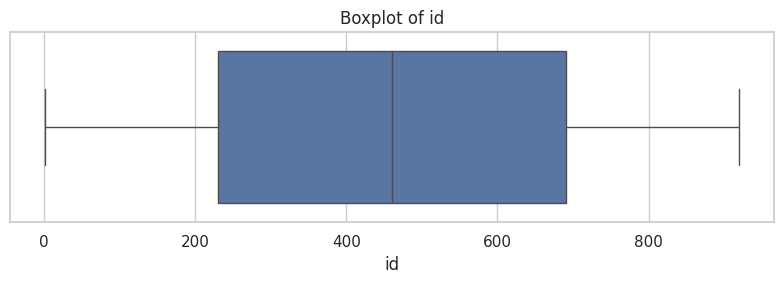


=== Outlier Analysis: id ===
Q1: 230.75
Q3: 690.25
IQR: 459.50
Lower bound: -458.50
Upper bound: 1379.50
Potential outliers: 0
Outlier percentage: 0.00%


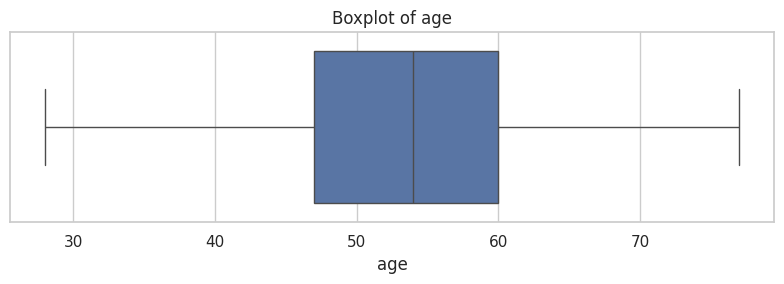


=== Outlier Analysis: age ===
Q1: 47.00
Q3: 60.00
IQR: 13.00
Lower bound: 27.50
Upper bound: 79.50
Potential outliers: 0
Outlier percentage: 0.00%


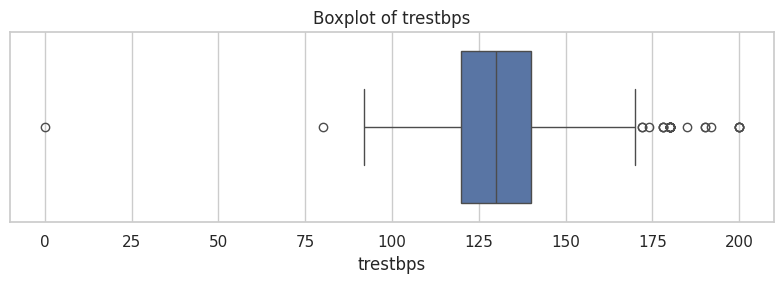


=== Outlier Analysis: trestbps ===
Q1: 120.00
Q3: 140.00
IQR: 20.00
Lower bound: 90.00
Upper bound: 170.00
Potential outliers: 28
Outlier percentage: 3.25%


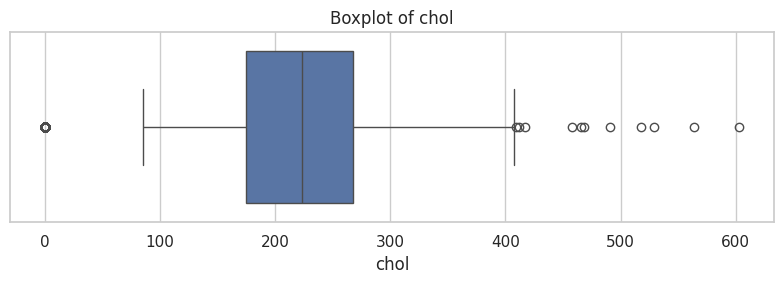


=== Outlier Analysis: chol ===
Q1: 175.00
Q3: 268.00
IQR: 93.00
Lower bound: 35.50
Upper bound: 407.50
Potential outliers: 183
Outlier percentage: 20.56%


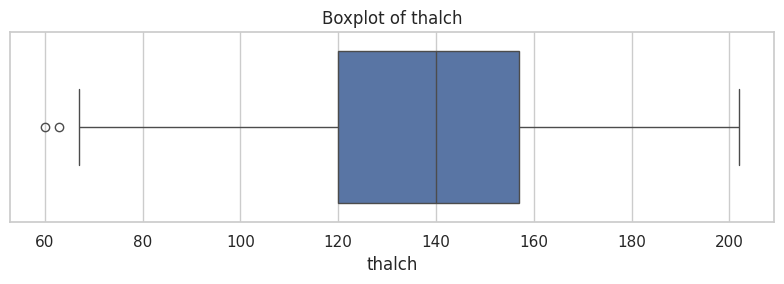


=== Outlier Analysis: thalch ===
Q1: 120.00
Q3: 157.00
IQR: 37.00
Lower bound: 64.50
Upper bound: 212.50
Potential outliers: 2
Outlier percentage: 0.23%


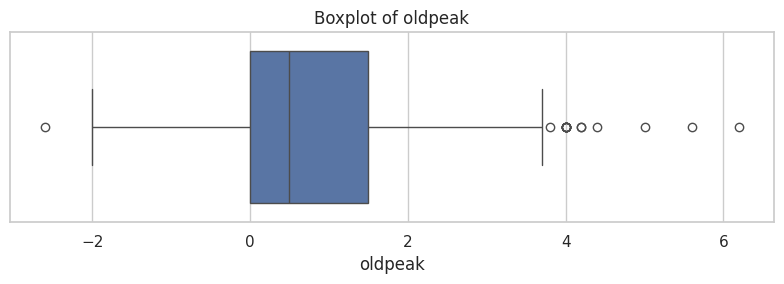


=== Outlier Analysis: oldpeak ===
Q1: 0.00
Q3: 1.50
IQR: 1.50
Lower bound: -2.25
Upper bound: 3.75
Potential outliers: 16
Outlier percentage: 1.86%


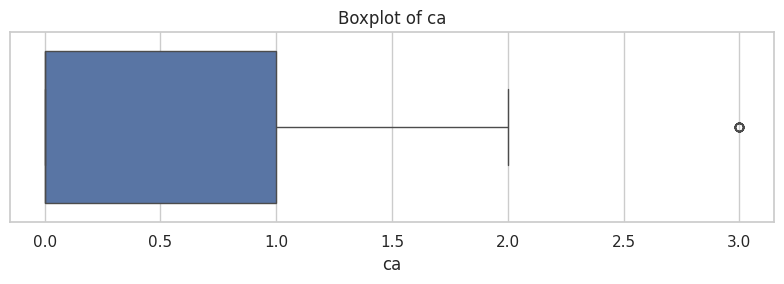


=== Outlier Analysis: ca ===
Q1: 0.00
Q3: 1.00
IQR: 1.00
Lower bound: -1.50
Upper bound: 2.50
Potential outliers: 20
Outlier percentage: 6.47%


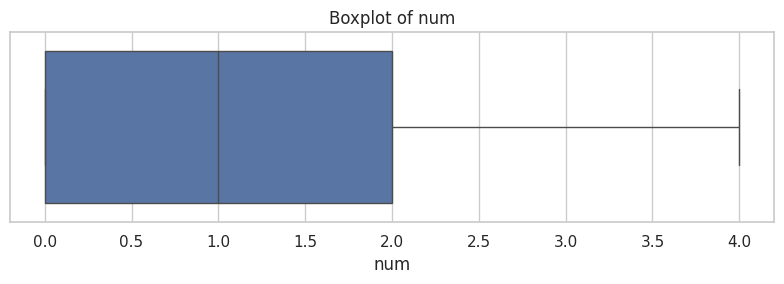


=== Outlier Analysis: num ===
Q1: 0.00
Q3: 2.00
IQR: 2.00
Lower bound: -3.00
Upper bound: 5.00
Potential outliers: 0
Outlier percentage: 0.00%


In [9]:
# Use boxplots to identify potential outliers in numerical features.
for col in numeric_cols:

    plt.figure(figsize=(8, 3))

    sns.boxplot(x=eda_df[col])

    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

    series = eda_df[col].dropna()

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = series[
        (series < lower_bound) |
        (series > upper_bound)
    ]

    print(f"\n=== Outlier Analysis: {col} ===")
    print(f"Q1: {q1:.2f}")
    print(f"Q3: {q3:.2f}")
    print(f"IQR: {iqr:.2f}")
    print(f"Lower bound: {lower_bound:.2f}")
    print(f"Upper bound: {upper_bound:.2f}")
    print(f"Potential outliers: {len(outliers)}")
    print(f"Outlier percentage: {len(outliers) / len(series) * 100:.2f}%")

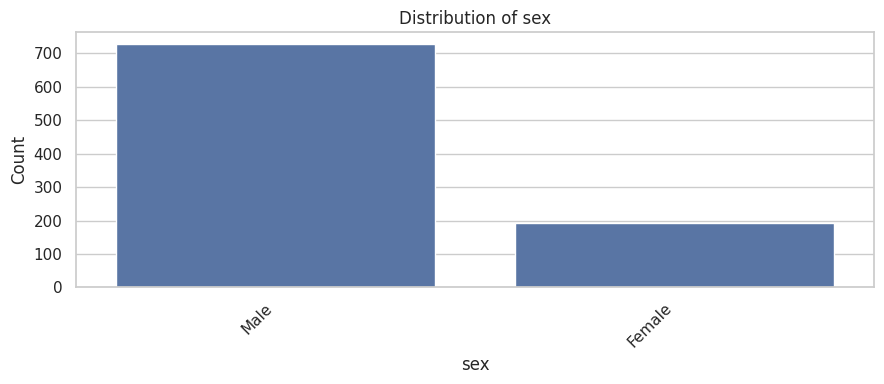


=== Categorical Analysis: sex ===
- Male: 726 samples (78.91%)
- Female: 194 samples (21.09%)


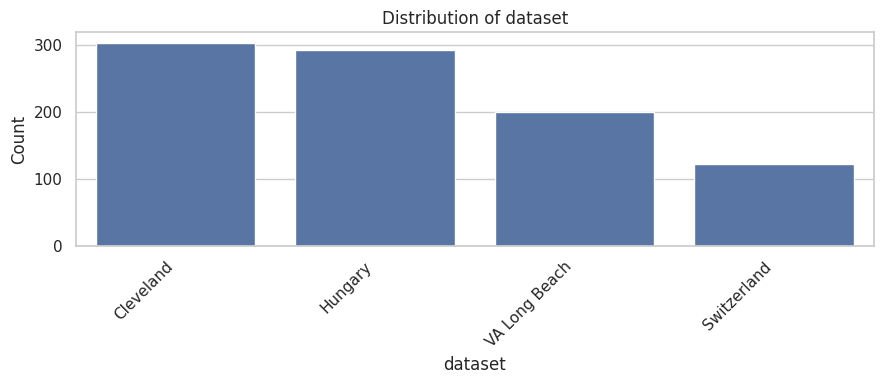


=== Categorical Analysis: dataset ===
- Cleveland: 304 samples (33.04%)
- Hungary: 293 samples (31.85%)
- VA Long Beach: 200 samples (21.74%)
- Switzerland: 123 samples (13.37%)


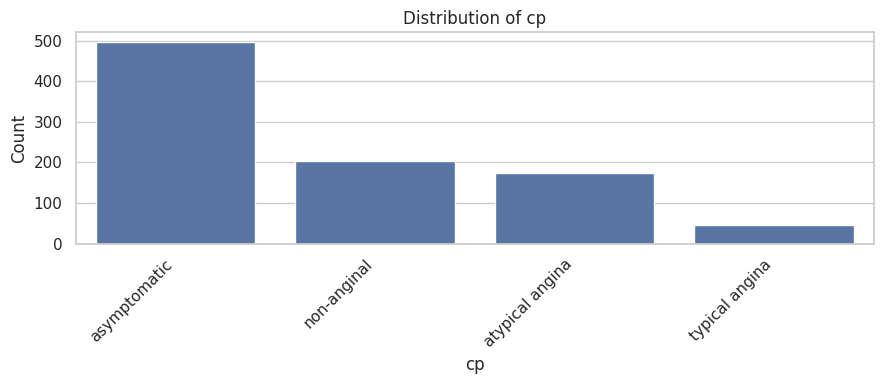


=== Categorical Analysis: cp ===
- asymptomatic: 496 samples (53.91%)
- non-anginal: 204 samples (22.17%)
- atypical angina: 174 samples (18.91%)
- typical angina: 46 samples (5.00%)


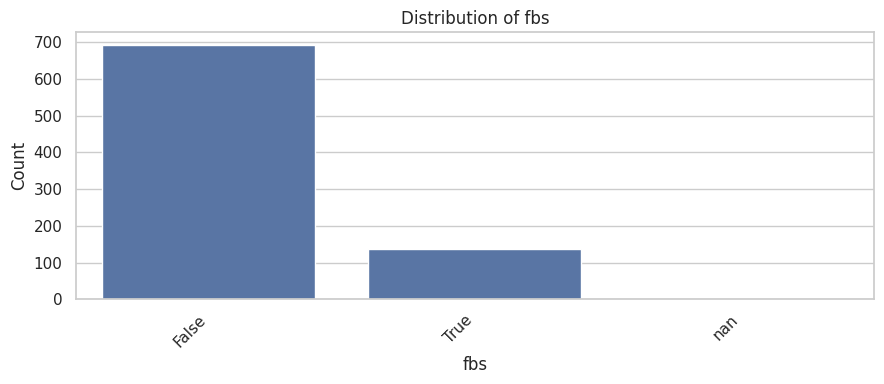


=== Categorical Analysis: fbs ===
- False: 692 samples (75.22%)
- True: 138 samples (15.00%)
- nan: 90 samples (9.78%)


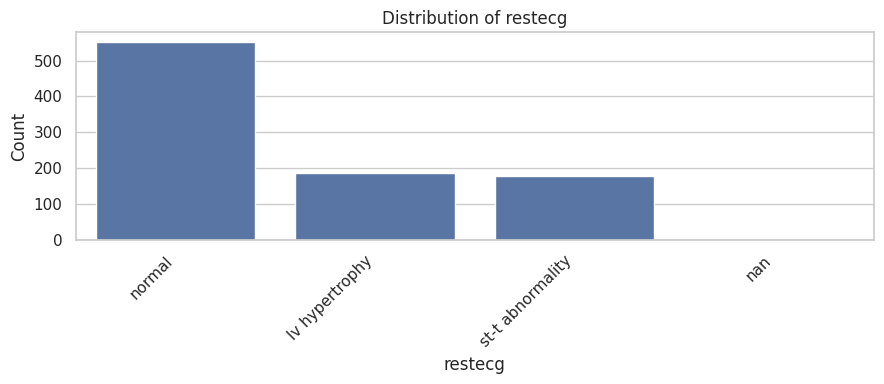


=== Categorical Analysis: restecg ===
- normal: 551 samples (59.89%)
- lv hypertrophy: 188 samples (20.43%)
- st-t abnormality: 179 samples (19.46%)
- nan: 2 samples (0.22%)


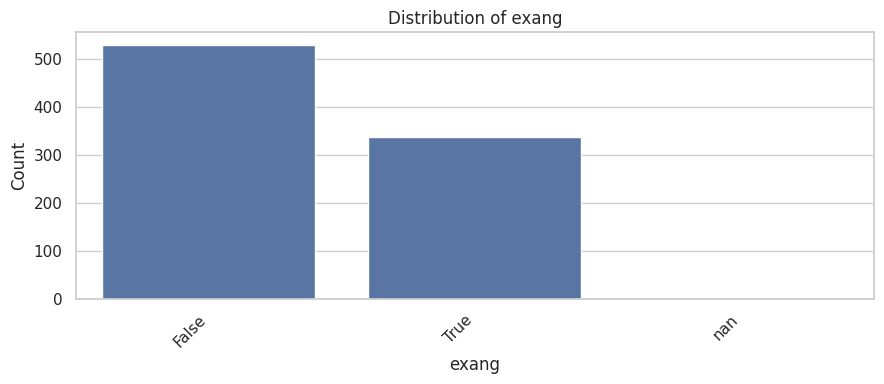


=== Categorical Analysis: exang ===
- False: 528 samples (57.39%)
- True: 337 samples (36.63%)
- nan: 55 samples (5.98%)


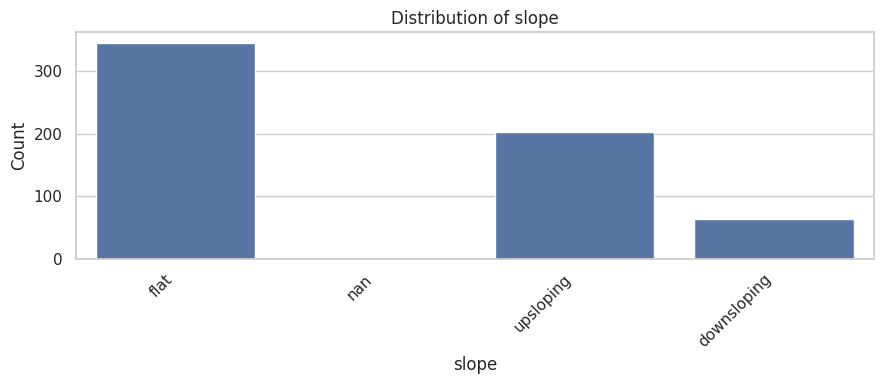


=== Categorical Analysis: slope ===
- flat: 345 samples (37.50%)
- nan: 309 samples (33.59%)
- upsloping: 203 samples (22.07%)
- downsloping: 63 samples (6.85%)


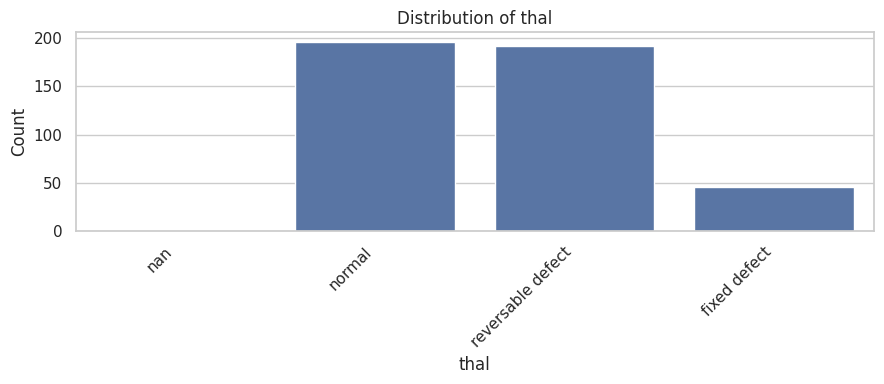


=== Categorical Analysis: thal ===
- nan: 486 samples (52.83%)
- normal: 196 samples (21.30%)
- reversable defect: 192 samples (20.87%)
- fixed defect: 46 samples (5.00%)


In [10]:
# Analyze the frequency distribution of categorical features.
for col in categorical_cols:

    counts = eda_df[col].value_counts(dropna=False)

    plt.figure(figsize=(9, 4))

    sns.countplot(
        data=eda_df,
        x=col,
        order=counts.index
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    print(f"\n=== Categorical Analysis: {col} ===")

    percentages = counts / len(eda_df) * 100

    for category in counts.index:
        print(
            f"- {category}: "
            f"{counts[category]} samples "
            f"({percentages[category]:.2f}%)"
        )

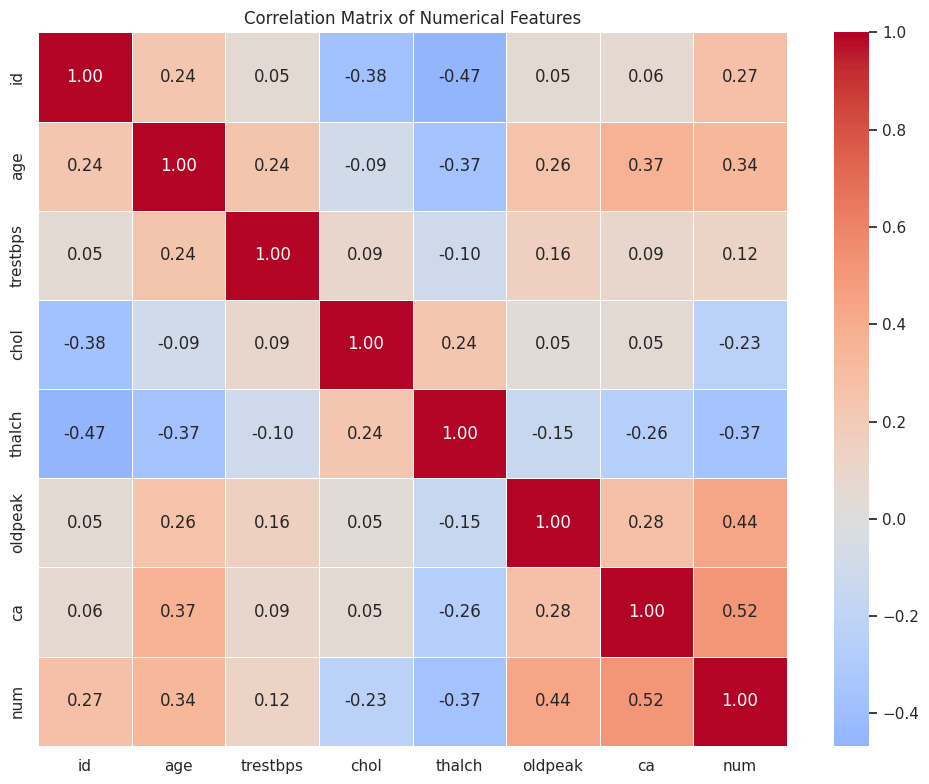

=== Strong Numerical Correlations ===
- id vs chol: -0.377
- id vs thalch: -0.466
- age vs thalch: -0.366
- age vs ca: +0.370
- age vs num: +0.340
- thalch vs num: -0.366
- oldpeak vs num: +0.443
- ca vs num: +0.516


In [11]:
# Calculate Pearson correlations between numerical variables.
corr_matrix = eda_df[numeric_cols].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

print("=== Strong Numerical Correlations ===")

# Report feature pairs with relatively strong correlations.
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):

        corr_value = corr_matrix.iloc[i, j]

        if abs(corr_value) >= 0.30:
            feature_1 = corr_matrix.columns[i]
            feature_2 = corr_matrix.columns[j]

            print(
                f"- {feature_1} vs {feature_2}: "
                f"{corr_value:+.3f}"
            )

In [12]:
# Measure the linear relationship between numerical features and the target.
target_correlations = (
    corr_matrix[target_col]
    .drop(target_col)
    .sort_values(key=abs, ascending=False)
)

print("=== Correlation with Target ===")

for feature, correlation in target_correlations.items():

    print(
        f"- {feature:<10} "
        f"Correlation: {correlation:+.3f}"
    )

strongest_feature = target_correlations.index[0]

print(
    f"\nStrongest numerical correlation with the target: "
    f"'{strongest_feature}' "
    f"({target_correlations.iloc[0]:+.3f})"
)

print(
    "\nNote: correlation measures linear association and should not "
    "be interpreted as proof of causation or overall feature importance."
)

=== Correlation with Target ===
- ca         Correlation: +0.516
- oldpeak    Correlation: +0.443
- thalch     Correlation: -0.366
- age        Correlation: +0.340
- id         Correlation: +0.274
- chol       Correlation: -0.232
- trestbps   Correlation: +0.122

Strongest numerical correlation with the target: 'ca' (+0.516)

Note: correlation measures linear association and should not be interpreted as proof of causation or overall feature importance.


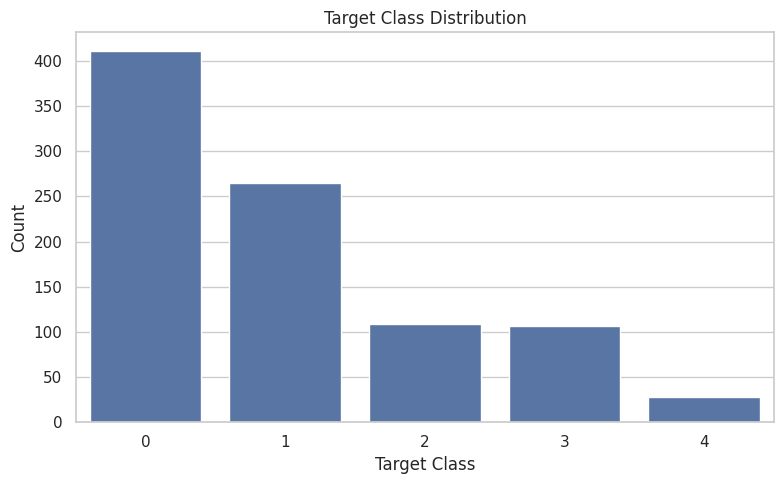

=== Target Distribution ===
- Class 0: 411 samples (44.67%)
- Class 1: 265 samples (28.80%)
- Class 2: 109 samples (11.85%)
- Class 3: 107 samples (11.63%)
- Class 4: 28 samples (3.04%)

Largest-to-smallest class percentage ratio: 14.68
Result: The target distribution is imbalanced. Accuracy alone should not be used as the primary evaluation metric.


In [13]:
# Analyze the distribution of the target variable.
target_counts = eda_df[target_col].value_counts().sort_index()
target_percentages = target_counts / len(eda_df) * 100

plt.figure(figsize=(8, 5))

sns.countplot(
    data=eda_df,
    x=target_col,
    order=target_counts.index
)

plt.title("Target Class Distribution")
plt.xlabel("Target Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("=== Target Distribution ===")

for cls in target_counts.index:

    print(
        f"- Class {cls}: "
        f"{target_counts[cls]} samples "
        f"({target_percentages[cls]:.2f}%)"
    )

max_percentage = target_percentages.max()
min_percentage = target_percentages.min()

imbalance_ratio = max_percentage / min_percentage

print(f"\nLargest-to-smallest class percentage ratio: {imbalance_ratio:.2f}")

if imbalance_ratio > 1.5:
    print(
        "Result: The target distribution is imbalanced. "
        "Accuracy alone should not be used as the primary evaluation metric."
    )
else:
    print(
        "Result: The target distribution is relatively balanced."
    )

Selected features for target comparison:
['ca', 'oldpeak', 'thalch']


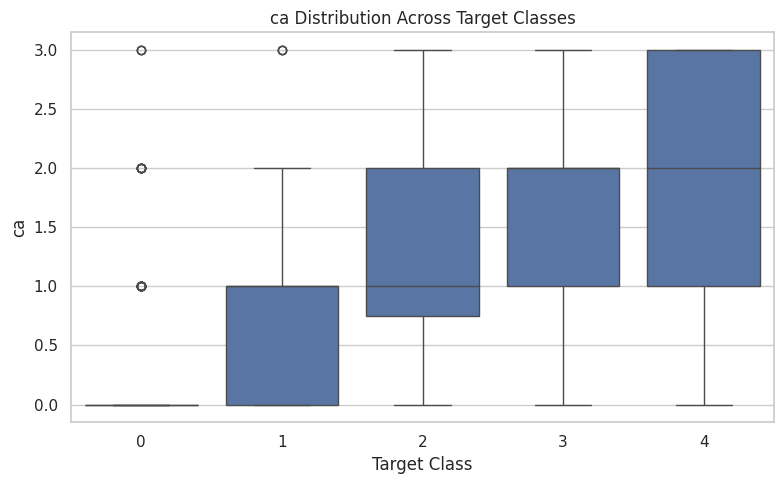


=== ca by Target Class ===
     count      mean  median
num                         
0      165  0.278788     0.0
1       58  0.741379     1.0
2       36  1.222222     1.0
3       37  1.459459     2.0
4       13  1.692308     2.0


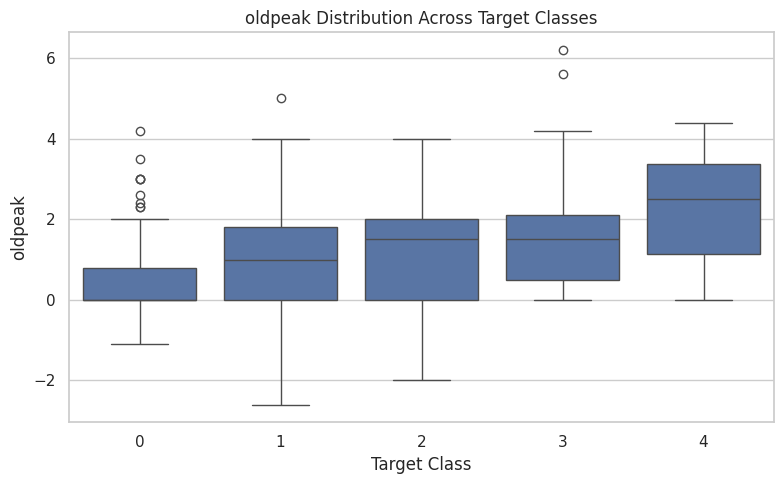


=== oldpeak by Target Class ===
     count      mean  median
num                         
0      390  0.418205     0.0
1      250  1.001200     1.0
2      101  1.353465     1.5
3       91  1.581319     1.5
4       26  2.307692     2.5


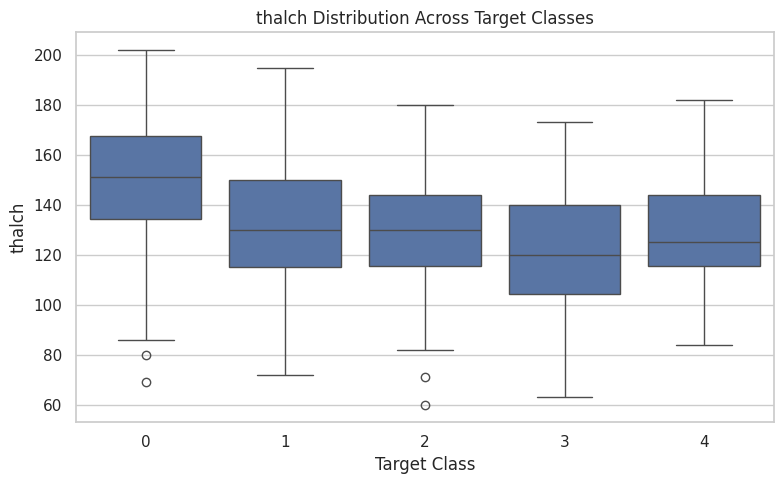


=== thalch by Target Class ===
     count        mean  median
num                           
0      391  148.800512   151.0
1      252  131.035714   130.0
2      102  128.666667   130.0
3       94  120.500000   120.0
4       26  127.846154   125.0


In [14]:
# Select numerical features with the strongest absolute correlation with the target.
important_features = (
    target_correlations
    .abs()
    .sort_values(ascending=False)
    .head(3)
    .index
    .tolist()
)

print("Selected features for target comparison:")
print(important_features)

for feature in important_features:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=eda_df,
        x=target_col,
        y=feature
    )

    plt.title(f"{feature} Distribution Across Target Classes")
    plt.xlabel("Target Class")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

    print(f"\n=== {feature} by Target Class ===")

    grouped = (
        eda_df
        .groupby(target_col)[feature]
        .agg(["count", "mean", "median"])
    )

    print(grouped)

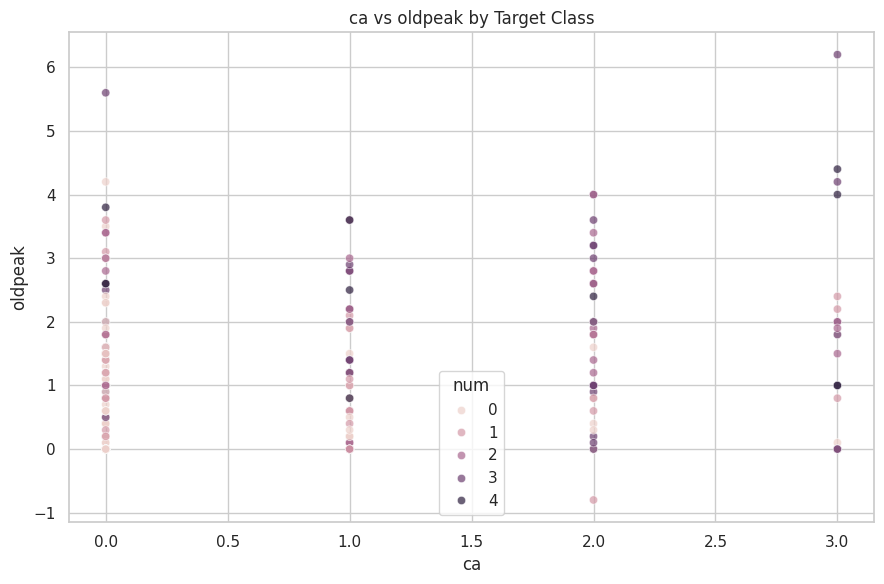

=== Feature Relationship Analysis ===
Correlation between ca and oldpeak: +0.282

The scatter plot can reveal whether the target classes show clear separation or substantial overlap.


In [15]:
# Compare selected numerical features to identify possible relationships.
if len(important_features) >= 2:

    feature_x = important_features[0]
    feature_y = important_features[1]

    plt.figure(figsize=(9, 6))

    sns.scatterplot(
        data=eda_df,
        x=feature_x,
        y=feature_y,
        hue=target_col,
        alpha=0.7
    )

    plt.title(
        f"{feature_x} vs {feature_y} by Target Class"
    )

    plt.xlabel(feature_x)
    plt.ylabel(feature_y)
    plt.tight_layout()
    plt.show()

    pair_correlation = eda_df[[feature_x, feature_y]].corr().iloc[0, 1]

    print("=== Feature Relationship Analysis ===")
    print(
        f"Correlation between {feature_x} and {feature_y}: "
        f"{pair_correlation:+.3f}"
    )

    print(
        "\nThe scatter plot can reveal whether the target classes "
        "show clear separation or substantial overlap."
    )

In [16]:
# Check numerical columns for suspicious zero or negative values.
print("=== Potential Data Quality Issues ===")

for col in numeric_cols:

    zero_count = (eda_df[col] == 0).sum()
    negative_count = (eda_df[col] < 0).sum()

    if zero_count > 0:
        print(
            f"- {col}: {zero_count} zero values detected."
        )

    if negative_count > 0:
        print(
            f"- {col}: {negative_count} negative values detected."
        )

print(
    "\nThese values are not automatically treated as errors. "
    "Their validity should be assessed using domain knowledge before preprocessing."
)

=== Potential Data Quality Issues ===
- trestbps: 1 zero values detected.
- chol: 172 zero values detected.
- oldpeak: 370 zero values detected.
- oldpeak: 12 negative values detected.
- ca: 181 zero values detected.
- num: 411 zero values detected.

These values are not automatically treated as errors. Their validity should be assessed using domain knowledge before preprocessing.


In [17]:
# Generate a compact summary of the main EDA findings.
print("=" * 60)
print("EDA SUMMARY")
print("=" * 60)

print(f"\nDataset size: {eda_df.shape[0]} rows x {eda_df.shape[1]} columns")

print("\nMissing values:")
for col, count in eda_df.isnull().sum().items():
    if count > 0:
        print(
            f"- {col}: {count} "
            f"({count / len(eda_df) * 100:.2f}%)"
        )

print("\nMost skewed numerical features:")

skew_summary = (
    eda_df[numeric_cols]
    .skew()
    .abs()
    .sort_values(ascending=False)
)

for feature in skew_summary.head(5).index:
    print(
        f"- {feature}: "
        f"skewness = {eda_df[feature].skew():+.2f}"
    )

print("\nStrongest numerical correlations with target:")

for feature in target_correlations.head(5).index:
    print(
        f"- {feature}: "
        f"{target_correlations[feature]:+.3f}"
    )

print("\nTarget distribution:")

for cls in target_counts.index:
    print(
        f"- Class {cls}: "
        f"{target_counts[cls]} "
        f"({target_percentages[cls]:.2f}%)"
    )

print("\nPotential data-quality concerns:")

for col in numeric_cols:

    zero_count = (eda_df[col] == 0).sum()

    if zero_count > 0:
        print(
            f"- {col}: {zero_count} zero values"
        )

print("\nRecommended next steps:")
print("- Handle missing values inside a preprocessing pipeline.")
print("- Review domain-invalid values before imputation.")
print("- Remove identifier columns such as 'id' from model features.")
print("- Encode categorical variables.")
print("- Scale numerical features for distance- or margin-based models.")
print("- Use stratified validation because the target classes are imbalanced.")
print("- Evaluate models with macro F1, recall, precision, and confusion matrix.")

EDA SUMMARY

Dataset size: 920 rows x 16 columns

Missing values:
- trestbps: 59 (6.41%)
- chol: 30 (3.26%)
- fbs: 90 (9.78%)
- restecg: 2 (0.22%)
- thalch: 55 (5.98%)
- exang: 55 (5.98%)
- oldpeak: 62 (6.74%)
- slope: 309 (33.59%)
- ca: 611 (66.41%)
- thal: 486 (52.83%)

Most skewed numerical features:
- ca: skewness = +1.17
- oldpeak: skewness = +1.04
- num: skewness = +0.97
- chol: skewness = -0.61
- trestbps: skewness = +0.21

Strongest numerical correlations with target:
- ca: +0.516
- oldpeak: +0.443
- thalch: -0.366
- age: +0.340
- id: +0.274

Target distribution:
- Class 0: 411 (44.67%)
- Class 1: 265 (28.80%)
- Class 2: 109 (11.85%)
- Class 3: 107 (11.63%)
- Class 4: 28 (3.04%)

Potential data-quality concerns:
- trestbps: 1 zero values
- chol: 172 zero values
- oldpeak: 370 zero values
- ca: 181 zero values
- num: 411 zero values

Recommended next steps:
- Handle missing values inside a preprocessing pipeline.
- Review domain-invalid values before imputation.
- Remove identif

In [18]:
# Save the numerical distribution analysis for later reference.
distribution_analysis.to_csv(
    "distribution_analysis.csv",
    index=False
)

# Save the target correlation analysis.
target_correlations.to_csv(
    "target_correlations.csv",
    header=["correlation"]
)

# Save the missing-value summary.
missing_summary.to_csv(
    "missing_value_summary.csv"
)

print("EDA summary files saved successfully.")

EDA summary files saved successfully.


# EDA Summary

## Dataset Overview

- The dataset contains **920 observations** and **16 variables**.
- The dataset includes both numerical and categorical features.
- No duplicate rows were detected.

## Missing Data

Several features contain missing values:

- `ca`: 66.41%
- `thal`: 52.83%
- `slope`: 33.59%
- `fbs`: 9.78%
- `oldpeak`: 6.74%
- `trestbps`: 6.41%
- `thalch`: 5.98%
- `exang`: 5.98%

The high proportion of missing values in `ca`, `thal`, and `slope` requires careful handling during preprocessing.

## Target Distribution

The target variable contains five classes:

- Class 0: 44.67%
- Class 1: 28.80%
- Class 2: 11.85%
- Class 3: 11.63%
- Class 4: 3.04%

The target is clearly imbalanced. Therefore, accuracy alone will not be sufficient for model evaluation.

## Numerical Relationships

The strongest numerical correlations with the target were:

- `ca`: +0.516
- `oldpeak`: +0.443
- `thalch`: -0.366
- `age`: +0.340

These correlations indicate linear associations only and should not be interpreted as causal relationships or definitive measures of feature importance.

## Data Quality Observations

Several potentially problematic values were identified:

- Zero values in `trestbps`
- A substantial number of zero values in `chol`
- Negative values in `oldpeak`
- Zero values in `ca`

These observations should be reviewed using domain knowledge before deciding whether they represent valid values, missing-value encodings, or data-quality issues.

## Modeling Implications

Based on the EDA findings:

1. Missing values should be handled inside a reproducible preprocessing pipeline.
2. Categorical variables require appropriate encoding.
3. The `id` column should be excluded from model features because it is an identifier.
4. Numerical features may require scaling depending on the selected algorithms.
5. Stratified validation should be used because the target classes are imbalanced.
6. Model evaluation should include macro F1-score, precision, recall, and a confusion matrix rather than relying only on accuracy.
7. Suspicious numerical values should be addressed using domain-aware preprocessing decisions.